# Modèle 1 — Régression linéaire (Linear Regression)

**Projet :** Electio-Analytics — MSPR EPSI 2026  
**Données :** `outputs/warehouse/dm_dataset_ml.csv`

### Problématique

> Prédire le **taux de participation** 2027 à partir des données 2012–2022 (Pays de la Loire).

**Cible :** `taux_participation_reel`

## Qu'est-ce que la régression linéaire ?

- **Idée :** participation = a₁×chômage + a₂×pauvreté + … + b
- **Avantages :** simple, rapide, facile à expliquer au client Electio-Analytics
- **Limites :** suppose une relation linéaire

**Pourquoi ce modèle ?** Baseline de référence pour comparer Ridge et Random Forest.

## Étape 1 — Configuration et imports

In [1]:
# ── Imports et chemins ───────────────────────────────────────────────────
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import LeaveOneOut, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Racine projet (dossier ml/ -> parent = MSPRDATAFINAL)
ROOT_DIR = Path("..").resolve()
INPUT_PATH = ROOT_DIR / "outputs" / "warehouse" / "dm_dataset_ml.csv"
OUTPUT_DIR = ROOT_DIR / "outputs" / "datamarts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "taux_participation_reel"
EXCLUDED_COLS = {
    "id_election", "load_ts", "famille_dominante", "taux_abstention_reel",
}

print("✅ Imports OK")
print(f"   Dataset : {INPUT_PATH}")


✅ Imports OK
   Dataset : /Users/adhamaitreqba/Desktop/MSPR/MSPRDATAFINAL/outputs/warehouse/dm_dataset_ml.csv


## Étape 2 — Chargement des données

In [2]:
# ── Chargement du datamart ML (sortie ETL de ton amie) ───────────────────
df = pd.read_csv(INPUT_PATH)

print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print("\nÉlections disponibles :")
print(df[["id_election", "annee", "type_election", TARGET]].to_string(index=False))


Dimensions : dataset commune-election genere par l ETL

Élections disponibles :
 id_election  annee type_election  taux_participation_reel
2012_legi_t1   2012          legi                  57.0785
2012_pres_t1   2012          pres                  80.2626
2017_legi_t1   2017          legi                  52.5397
2017_pres_t1   2017          pres                  80.0309
2022_legi_t1   2022          legi                  50.0399
2022_pres_t1   2022          pres                  73.9957


## Étape 3 — Préparation des features

In [3]:
# ── Préparation X (features) et y (cible) ──────────────────────────────
work = df.dropna(subset=[TARGET]).copy()

# On retire les colonnes qui fuient l'info cible ou qui ne servent pas au ML
drop_cols = [c for c in EXCLUDED_COLS if c in work.columns]
work = work.drop(columns=drop_cols)

X = work.drop(columns=[TARGET])
y = work[TARGET]

# Variables numériques uniquement (POC robuste)
X = X.select_dtypes(include=[np.number]).copy()

print(f"Observations : {len(X)}")
print(f"Variables explicatives : {X.shape[1]}")
print(f"Cible : {TARGET} (min={y.min():.2f}, max={y.max():.2f})")


Observations : 6
Variables explicatives : 49
Cible : taux_participation_reel (min=50.04, max=80.26)


## Étape 4 — Construction du pipeline

In [4]:
from sklearn.linear_model import LinearRegression

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
print("✅ Pipeline LinearRegression prêt")
print(pipe)

✅ Pipeline LinearRegression prêt
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', LinearRegression())])


## Étape 5 — Évaluation Leave-One-Out (résultats par élection)

In [5]:
# ── Validation Leave-One-Out + détail fold par fold ─────────────────────
# On utilise une validation croisee adaptee au dataset commune-election.

cv = LeaveOneOut()
fold_rows = []

for fold_id, (train_idx, test_idx) in enumerate(cv.split(X), start=1):
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred = pipe.predict(X.iloc[test_idx])[0]
    y_true = y.iloc[test_idx].values[0]
    election = df.loc[test_idx[0], "id_election"] if "id_election" in df.columns else f"fold_{fold_id}"

    fold_rows.append({
        "fold": fold_id,
        "id_election": election,
        "y_reel": round(float(y_true), 4),
        "y_pred": round(float(y_pred), 4),
        "erreur_abs": round(abs(float(y_true) - float(y_pred)), 4),
    })

df_folds = pd.DataFrame(fold_rows)
rmse = float(np.sqrt(((df_folds["y_reel"] - df_folds["y_pred"]) ** 2).mean()))
mae = float(df_folds["erreur_abs"].mean())

print("=== Résultats fold par fold ===")
print(df_folds.to_string(index=False))
print(f"\nRMSE (manuel) : {rmse:.4f}")
print(f"MAE  (manuel)  : {mae:.4f}")


=== Résultats fold par fold ===
 fold  id_election  y_reel  y_pred  erreur_abs
    1 2012_legi_t1 57.0785 67.1983     10.1198
    2 2012_pres_t1 80.2626 78.2686      1.9940
    3 2017_legi_t1 52.5397 54.9498      2.4101
    4 2017_pres_t1 80.0309 77.2064      2.8245
    5 2022_legi_t1 50.0399 60.1495     10.1096
    6 2022_pres_t1 73.9957 68.6779      5.3178

RMSE (manuel) : 6.4634
MAE  (manuel)  : 5.4626


In [6]:
# ── Cross-validation sklearn (même métriques, vérification) ───────────
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}

scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)
print("RMSE sklearn :", round(-scores["test_rmse"].mean(), 4))
print("MAE  sklearn :", round(-scores["test_mae"].mean(), 4))


RMSE sklearn : 5.4626
MAE  sklearn : 5.4626


## Étape 6 — Visualisation

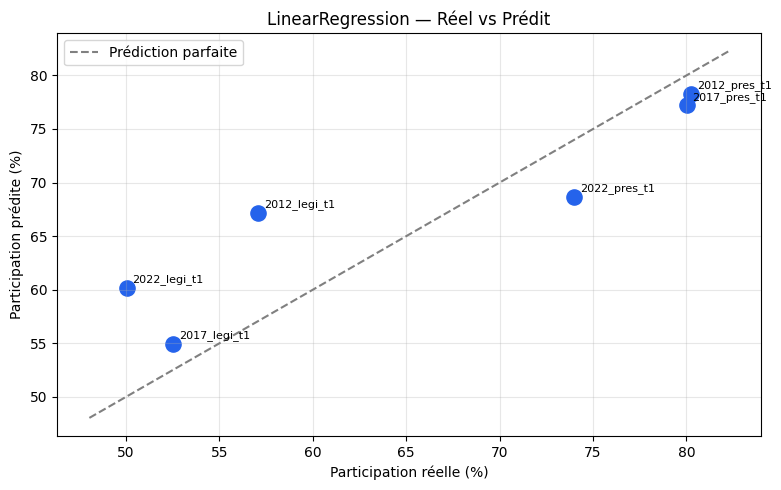

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df_folds["y_reel"], df_folds["y_pred"], s=120, color="#2563eb")
for _, row in df_folds.iterrows():
    plt.annotate(row["id_election"], (row["y_reel"], row["y_pred"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
min_v = min(df_folds["y_reel"].min(), df_folds["y_pred"].min()) - 2
max_v = max(df_folds["y_reel"].max(), df_folds["y_pred"].max()) + 2
plt.plot([min_v, max_v], [min_v, max_v], "--", color="gray", label="Prédiction parfaite")
plt.xlabel("Participation réelle (%)")
plt.ylabel("Participation prédite (%)")
plt.title("LinearRegression — Réel vs Prédit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Étape 7 — Export des résultats

In [8]:
out_csv = OUTPUT_DIR / "ml_linear_regression_results.csv"
out_png = OUTPUT_DIR / "ml_linear_regression_plot.png"

pd.DataFrame([{"model": "LinearRegression", "RMSE": rmse, "MAE": mae, "n_obs": len(X), "cv": "LeaveOneOut"}]).to_csv(out_csv, index=False)

plt.figure(figsize=(8, 5))
plt.scatter(df_folds["y_reel"], df_folds["y_pred"], s=120)
plt.plot([min_v, max_v], [min_v, max_v], "--", color="gray")
plt.xlabel("Participation réelle (%)")
plt.ylabel("Participation prédite (%)")
plt.title("LinearRegression")
plt.tight_layout()
plt.savefig(out_png, dpi=150)
plt.close()
print(f"✅ Export : {out_csv}")
print(f"✅ Export : {out_png}")

✅ Export : /Users/adhamaitreqba/Desktop/MSPR/MSPRDATAFINAL/outputs/datamarts/ml_linear_regression_results.csv
✅ Export : /Users/adhamaitreqba/Desktop/MSPR/MSPRDATAFINAL/outputs/datamarts/ml_linear_regression_plot.png


## Conclusion

Modèle le plus **interprétable**. Compare RMSE avec notebooks 02 et 03.